In [ ]:
!pip install kagglehub

In [ ]:
!pip install idx2numpy


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Path to dataset files: C:\Users\DELL\.cache\kagglehub\datasets\hojjatk\mnist-dataset\versions\1
Dataset loaded successfully.
Shape of training images (X_train): (60000, 28, 28)
Shape of training labels (y_train): (60000,)
Shape of test images (X_test): (10000, 28, 28)
Shape of test labels (y_test): (10000,)
Class distribution in training labels (y_train):
Digit 0: 5923 samples (9.87%)
Digit 1: 6742 samples (11.24%)
Digit 2: 5958 samples (9.93%)
Digit 3: 6131 samples (10.22%)
Digit 4: 5842 samples (9.74%)
Digit 5: 5421 samples (9.04%)
Digit 6: 5918 samples (9.86%)
Digit 7: 6265 samples (10.44%)
Digit 8: 5851 samples (9.75%)
Digit 9: 5949 samples (9.92%)


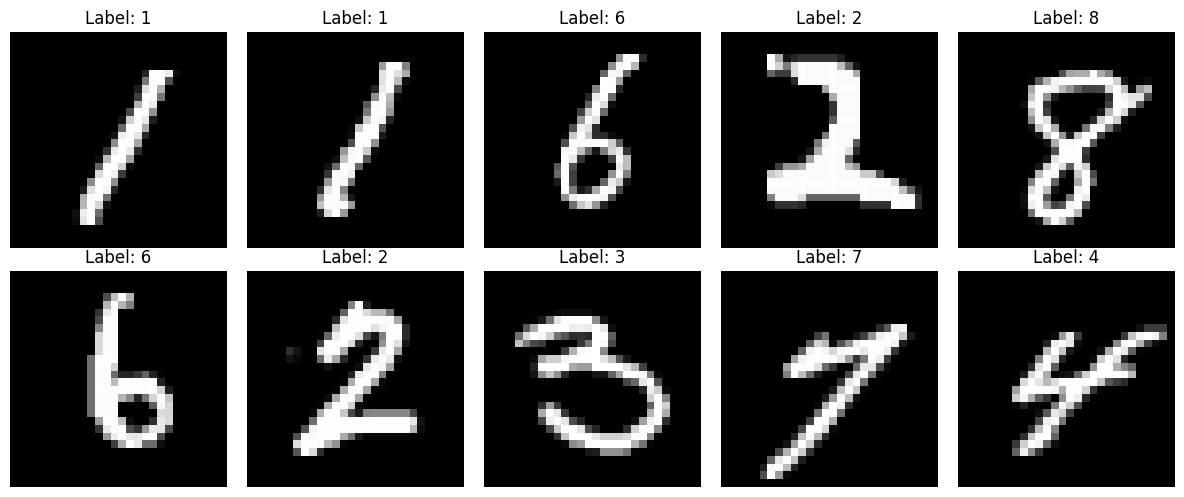

Data preprocessing complete.
New shape of training images (X_train): (60000, 28, 28, 1)
New shape of training labels (y_train): (60000, 10)
New shape of test images (X_test): (10000, 28, 28, 1)
New shape of test labels (y_test): (10000, 10)
CNN Model Architecture:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)                    │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Model compiled successfully with Adam optimizer, categorical_crossentropy loss, and accuracy metric.
Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 12ms/step - accuracy: 0.9099 - loss: 0.2912 - val_accuracy: 0.9849 - val_loss: 0.0450
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 11ms/step - accuracy: 0.9864 - loss: 0.0431 - val_accuracy: 0.9884 - val_loss: 0.0334
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - accuracy: 0.9909 - loss: 0.0271 - val_accuracy: 0.9903 - val_loss: 0.0316
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 11ms/step - accuracy: 0.9939 - loss: 0.0200 - val_accuracy: 0.9897 - val_loss: 0.0364
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9959 - loss: 0.0134 - val_accuracy: 0.9891 - val_loss: 0.0370
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9966 - loss: 0.0105 - val_accuracy: 0.9892 - val_loss: 0.0381
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9965 - loss: 0.0104 - val_accuracy: 0

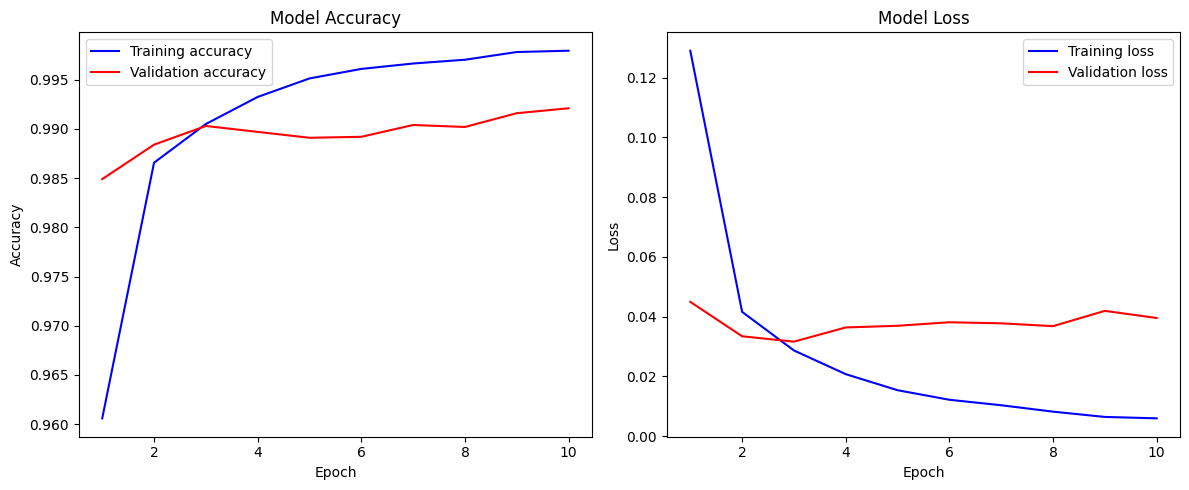

In [11]:
import kagglehub
import os
import idx2numpy
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# --- 1. Install necessary libraries ---
# Ensure idx2numpy is installed
!pip install idx2numpy

# --- 2. Load and Inspect Data ---
# Download dataset from Kaggle Hub
path = kagglehub.dataset_download("hojjatk/mnist-dataset")
print("Path to dataset files:", path)

# Define the file names for MNIST dataset
train_images_file = os.path.join(path, 'train-images.idx3-ubyte')
train_labels_file = os.path.join(path, 'train-labels.idx1-ubyte')
test_images_file = os.path.join(path, 't10k-images.idx3-ubyte')
test_labels_file = os.path.join(path, 't10k-labels.idx1-ubyte')

# Load the dataset using idx2numpy
X_train = idx2numpy.convert_from_file(train_images_file)
y_train = idx2numpy.convert_from_file(train_labels_file)
X_test = idx2numpy.convert_from_file(test_images_file)
y_test = idx2numpy.convert_from_file(test_labels_file)

print("Dataset loaded successfully.")

# Display dataset shapes
print(f"Shape of training images (X_train): {X_train.shape}")
print(f"Shape of training labels (y_train): {y_train.shape}")
print(f"Shape of test images (X_test): {X_test.shape}")
print(f"Shape of test labels (y_test): {y_test.shape}")

# Calculate and display class distribution
unique_labels, counts = np.unique(y_train, return_counts=True)
print("Class distribution in training labels (y_train):")
for label, count in zip(unique_labels, counts):
    percentage = (count / len(y_train)) * 100
    print(f"Digit {label}: {count} samples ({percentage:.2f}%)")

# Display 10 random sample images with their labels
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

for i in range(10):
    index = np.random.randint(0, len(X_train)) # Select a random index
    axes[i].imshow(X_train[index], cmap='gray')
    axes[i].set_title(f"Label: {y_train[index]}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# --- 3. Preprocess Data ---
# 1. Convert to float and normalize pixel values to 0-1
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# 2. Reshape image data to include a channel dimension
# MNIST images are 28x28, so we reshape to (28, 28, 1)
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# 3. Convert labels to one-hot encoded format
y_train = tf.keras.utils.to_categorical(y_train, num_classes=10)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=10)

print("Data preprocessing complete.")

# 4. Print the new shapes of the processed data
print(f"New shape of training images (X_train): {X_train.shape}")
print(f"New shape of training labels (y_train): {y_train.shape}")
print(f"New shape of test images (X_test): {X_test.shape}")
print(f"New shape of test labels (y_test): {y_test.shape}")

# --- 4. Build CNN Model ---
# Initialize a Sequential model
model = Sequential()

# Add Conv2D, MaxPooling2D, Flatten, and Dense layers
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(10, activation='softmax')) # Output layer for 10 classes

# Print the model summary
print("CNN Model Architecture:")
model.summary()

# --- 5. Compile and Train Model ---
# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("Model compiled successfully with Adam optimizer, categorical_crossentropy loss, and accuracy metric.")

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)

print("Model training complete.")

# --- 6. Evaluate Model Performance ---
print("\nEvaluating model performance on the test dataset...")
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# Access training history
history_dict = history.history
acc = history_dict['accuracy']
val_acc = history_dict['val_accuracy']
loss = history_dict['loss']
val_loss = history_dict['val_loss']

epochs = range(1, len(acc) + 1)

# Plot training and validation accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'b', label='Training accuracy')
plt.plot(epochs, val_acc, 'r', label='Validation accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'b', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()